
АВАРИЯ: итп
Отключено узлов: 10
Квартир без ресурса: 0


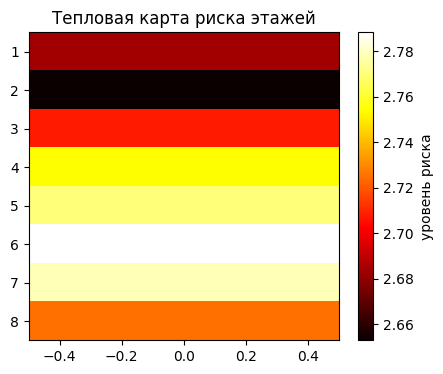

In [ ]:
# ======================================================
# DIGITAL TWIN ЗДАНИЯ
# РЕАЛИСТИЧНАЯ СХЕМА ИТП + ТЕПЛОСЕТЬ
# ======================================================

import networkx as nx
import plotly.graph_objects as go
import numpy as np
import random
import matplotlib.pyplot as plt

# ------------------------------------------------
# ПАРАМЕТРЫ ДОМА
# ------------------------------------------------

floors = 8
apartments_per_floor = 4
house_age = 25

# ------------------------------------------------
# ФУНКЦИЯ ВОЗРАСТА СИСТЕМ
# ------------------------------------------------

def get_actual_age(system_type):

    if random.random() < 0.2:
        return random.uniform(0,5)

    return max(0, house_age + random.uniform(-5,5))

age_system = {t: get_actual_age(t) for t in
["хвс","гвс","отопление","канализация","щит","итп","грщ","лифт"]}

age_system["моп"] = house_age
age_system["квартира"] = 5


# ------------------------------------------------
# СОЗДАНИЕ ГРАФА
# ------------------------------------------------

G = nx.Graph()

pos={}
types={}

# ------------------------------------------------
# ПОДВАЛ
# ------------------------------------------------

# ввод теплосети
G.add_node("ввод_теплосети")
types["ввод_теплосети"]="теплосеть"
pos["ввод_теплосети"]=(-2,-5,-1)

# ИТП
G.add_node("итп")
types["итп"]="итп"
pos["итп"]=(0,-4,-1)

G.add_edge("ввод_теплосети","итп")

# ввод холодной воды
G.add_node("ввод_хвс")
types["ввод_хвс"]="хвс"
pos["ввод_хвс"]=(-4,-5,-1)

# канализационный коллектор
G.add_node("коллектор_канализации")
types["коллектор_канализации"]="канализация"
pos["коллектор_канализации"]=(4,-5,-1)

# ------------------------------------------------
# МАГИСТРАЛИ
# ------------------------------------------------

basement_pos = {

"хвс":(-4,-3,-1),
"гвс":(-1,-3,-1),
"отопление":(1,-3,-1),
"канализация":(4,-3,-1)

}

for sys in ["хвс","гвс","отопление","канализация"]:

    node=f"магистраль_{sys}"

    G.add_node(node)
    types[node]=sys
    pos[node]=basement_pos[sys]


# соединения магистралей

G.add_edge("итп","магистраль_отопление")
G.add_edge("итп","магистраль_гвс")

G.add_edge("ввод_хвс","магистраль_хвс")

G.add_edge("магистраль_канализация","коллектор_канализации")


# ------------------------------------------------
# ЭТАЖИ
# ------------------------------------------------

for f in range(1,floors+1):

    lift=f"лифт_{f}"
    G.add_node(lift)
    types[lift]="лифт"
    pos[lift]=(0,0,f)

    mop=f"моп_{f}"
    G.add_node(mop)
    types[mop]="моп"
    pos[mop]=(1,1,f)

    shield=f"щит_{f}"
    G.add_node(shield)
    types[shield]="щит"
    pos[shield]=(2,1,f)

    for a in range(1,apartments_per_floor+1):

        apt=f"квартира_{f}_{a}"

        G.add_node(apt)
        types[apt]="квартира"

        angle=2*np.pi*a/apartments_per_floor

        pos[apt]=(6*np.cos(angle),6*np.sin(angle),f)

        G.add_edge(apt,mop)
        G.add_edge(apt,shield)

        systems=["хвс","гвс","отопление","канализация"]

        for i,sys in enumerate(systems):

            node=f"{sys}_{f}_{a}"

            G.add_node(node)
            types[node]=sys

            offset=(i-1.5)*0.4

            x=3*np.cos(angle)+offset
            y=3*np.sin(angle)+offset

            pos[node]=(x,y,f)

            G.add_edge(node,apt)


# ------------------------------------------------
# ВЕРТИКАЛЬНЫЕ СТОЯКИ
# ------------------------------------------------

for a in range(1,apartments_per_floor+1):

    for sys in ["хвс","гвс","отопление","канализация"]:

        for f in range(1,floors):

            G.add_edge(f"{sys}_{f}_{a}",f"{sys}_{f+1}_{a}")

        G.add_edge(f"{sys}_1_{a}",f"магистраль_{sys}")


# ------------------------------------------------
# CENTRALITY
# ------------------------------------------------

centrality = nx.betweenness_centrality(G)

# ------------------------------------------------
# КАСКАДНАЯ НАГРУЗКА
# ------------------------------------------------

def cascade_load(node):

    H=G.copy()
    H.remove_node(node)

    components=list(nx.connected_components(H))

    largest=max(components,key=len)

    lost=len(G.nodes())-len(largest)

    return lost

load={}

for n in G.nodes():

    load[n]=cascade_load(n)


# ------------------------------------------------
# КОЭФФИЦИЕНТЫ СИСТЕМ
# ------------------------------------------------

system_factor={

"квартира":0.5,
"моп":0.7,
"канализация":1.2,
"хвс":1.2,
"гвс":1.2,
"отопление":1.2,
"щит":1.4,
"грщ":1.5,
"лифт":1.6,
"итп":1.8,
"теплосеть":2

}

# ------------------------------------------------
# УЯЗВИМОСТЬ
# ------------------------------------------------

vulnerability={}

for n in G.nodes():

    t=types[n]

    age_factor=age_system.get(t,10)/30

    condition=random.uniform(0.8,1.2)

    vulnerability[n]=age_factor*condition*system_factor.get(t,1)


# ------------------------------------------------
# РИСК
# ------------------------------------------------

risk={}

for n in G.nodes():

    risk[n]=vulnerability[n]*(1+centrality[n])*(1+np.log1p(load[n]))


# ------------------------------------------------
# ЭКОНОМИЧЕСКИЙ РИСК
# ------------------------------------------------

cost_factor={

"квартира":2000,
"хвс":8000,
"гвс":8000,
"отопление":9000,
"канализация":10000,
"щит":7000,
"лифт":15000,
"итп":30000,
"теплосеть":50000

}

expected_cost={}

for n in G.nodes():

    base=cost_factor.get(types[n],5000)

    expected_cost[n]=base*(1+risk[n])*(1+load[n]/10)


# ------------------------------------------------
# 3D ГРАФ
# ------------------------------------------------

edge_x=[]
edge_y=[]
edge_z=[]

for e in G.edges():

    x0,y0,z0=pos[e[0]]
    x1,y1,z1=pos[e[1]]

    edge_x+=[x0,x1,None]
    edge_y+=[y0,y1,None]
    edge_z+=[z0,z1,None]

edge_trace=go.Scatter3d(

x=edge_x,
y=edge_y,
z=edge_z,

mode="lines",

line=dict(width=2,color="gray"),

hoverinfo="none"

)

node_x=[]
node_y=[]
node_z=[]
node_color=[]
node_size=[]
node_text=[]

vals=np.array(list(risk.values()))
norm=(vals-vals.min())/(vals.max()-vals.min())
risk_norm=dict(zip(G.nodes(),norm))

for n in G.nodes():

    x,y,z=pos[n]

    r=risk_norm[n]

    node_x.append(x)
    node_y.append(y)
    node_z.append(z)

    node_text.append(

        f"<b>{n}</b>"
        f"<br>тип: {types[n]}"
        f"<br>риск: {risk[n]:.2f}"
        f"<br>нагрузка: {load[n]}"
        f"<br>экономический риск: {expected_cost[n]:.0f}"

    )

    if r>0.75:
        node_color.append("purple")
        node_size.append(14)

    elif r>0.5:
        node_color.append("red")
        node_size.append(12)

    elif r>0.25:
        node_color.append("orange")
        node_size.append(10)

    else:
        node_color.append("green")
        node_size.append(7)


node_trace=go.Scatter3d(

x=node_x,
y=node_y,
z=node_z,

mode="markers",

marker=dict(size=node_size,color=node_color),

text=node_text,

hoverinfo="text"

)

fig=go.Figure(data=[edge_trace,node_trace])

fig.update_layout(

title=f"Digital Twin здания | {floors} этажей",

scene=dict(

xaxis=dict(visible=False),
yaxis=dict(visible=False),
zaxis=dict(title="Этаж")

)

)

fig.show()


# ------------------------------------------------
# СИМУЛЯЦИЯ АВАРИИ
# ------------------------------------------------

def simulate_failure(node):

    H=G.copy()
    H.remove_node(node)

    components=list(nx.connected_components(H))
    largest=max(components,key=len)

    lost=set(G.nodes())-set(largest)

    print("\nАВАРИЯ:",node)

    print("Отключено узлов:",len(lost))

    affected=[n for n in lost if types.get(n)=="квартира"]

    print("Квартир без ресурса:",len(affected))

    return lost


# пример
simulate_failure("итп")


# ------------------------------------------------
# ТЕПЛОВАЯ КАРТА РИСКА
# ------------------------------------------------

floor_risk=[]

for f in range(1,floors+1):

    vals=[]

    for n in G.nodes():

        if f"_{f}_" in n or f"_{f}" in n:

            vals.append(risk[n])

    floor_risk.append(np.mean(vals))

plt.figure(figsize=(5,4))

plt.imshow(np.array(floor_risk).reshape(-1,1),cmap="hot",aspect="auto")

plt.yticks(range(floors),range(1,floors+1))

plt.title("Тепловая карта риска этажей")

plt.colorbar(label="уровень риска")

plt.show()